# Exploratory Data Analysis (EDA) for Ola Ride Insights

This notebook contains the exploratory data analysis for the Ola Ride Insights project. The goal is to understand the ride-sharing data better through visualizations and statistical analysis.

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style='whitegrid')

In [7]:
# Load the data
df = pd.read_csv('../data/july_rides.csv')

# 1. Handle missing or inconsistent values
df = df.drop_duplicates()
df['Booking_Value'] = pd.to_numeric(df['Booking_Value'], errors='coerce')
df['Ride_Distance'] = pd.to_numeric(df['Ride_Distance'], errors='coerce')
df['Driver_Ratings'] = pd.to_numeric(df['Driver_Ratings'], errors='coerce')
df['Customer_Rating'] = pd.to_numeric(df['Customer_Rating'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Fill missing ratings with mean
df['Driver_Ratings'] = df['Driver_Ratings'].fillna(df['Driver_Ratings'].mean())
df['Customer_Rating'] = df['Customer_Rating'].fillna(df['Customer_Rating'].mean())

# Fill missing Booking_Value and Ride_Distance with median
df['Booking_Value'] = df['Booking_Value'].fillna(df['Booking_Value'].median())
df['Ride_Distance'] = df['Ride_Distance'].fillna(df['Ride_Distance'].median())

# 2. Convert data types and standardize formats
df['Booking_Status'] = df['Booking_Status'].str.title().str.strip()
df['Payment_Method'] = df['Payment_Method'].str.upper().str.strip()
df['Vehicle_Type'] = df['Vehicle_Type'].str.title().str.strip()

# 3. Create derived features (example: ride revenue per km)
df['Revenue_per_km'] = df['Booking_Value'] / df['Ride_Distance']

# Preview cleaned data
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Revenue_per_km
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled By Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Personal & Car related issue,NaN,NaN,444,NaN,0,3.997457,3.998313,https://cdn-icons-png.flaticon.com/128/14183/1...,inf
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,No,NaN,158,CASH,13,4.100000,4.000000,https://cdn-icons-png.flaticon.com/128/9983/99...,12.153846
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime Suv,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,No,NaN,386,UPI,40,4.200000,4.800000,https://cdn-icons-png.flaticon.com/128/9983/99...,9.650000
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled By Customer,CID581320,Ebike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,NaN,NaN,384,NaN,0,3.997457,3.998313,https://cdn-icons-png.flaticon.com/128/6839/68...,inf
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,No,NaN,822,CREDIT CARD,45,4.000000,3.000000,https://cdn-icons-png.flaticon.com/128/3202/32...,18.266667


In [5]:
# Summary of the dataset
import warnings
warnings.filterwarnings('ignore')
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[ns]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  object        
 3   Booking_Status              103024 non-null  object        
 4   Customer_ID                 103024 non-null  object        
 5   Vehicle_Type                103024 non-null  object        
 6   Pickup_Location             103024 non-null  object        
 7   Drop_Location               103024 non-null  object        
 8   V_TAT                       63967 non-null   float64       
 9   C_TAT                       63967 non-null   float64       
 10  Canceled_Rides_by_Customer  10499 non-null   object        
 11  Canceled_Rides_by_Driver    18434 non-n

Date                              0
Time                              0
Booking_ID                        0
Booking_Status                    0
Customer_ID                       0
Vehicle_Type                      0
Pickup_Location                   0
Drop_Location                     0
V_TAT                         39057
C_TAT                         39057
Canceled_Rides_by_Customer    92525
Canceled_Rides_by_Driver      84590
Incomplete_Rides              39057
Incomplete_Rides_Reason       99098
Booking_Value                     0
Payment_Method                39057
Ride_Distance                     0
Driver_Ratings                    0
Customer_Rating                   0
Vehicle Images                    0
Revenue_per_km                    0
dtype: int64

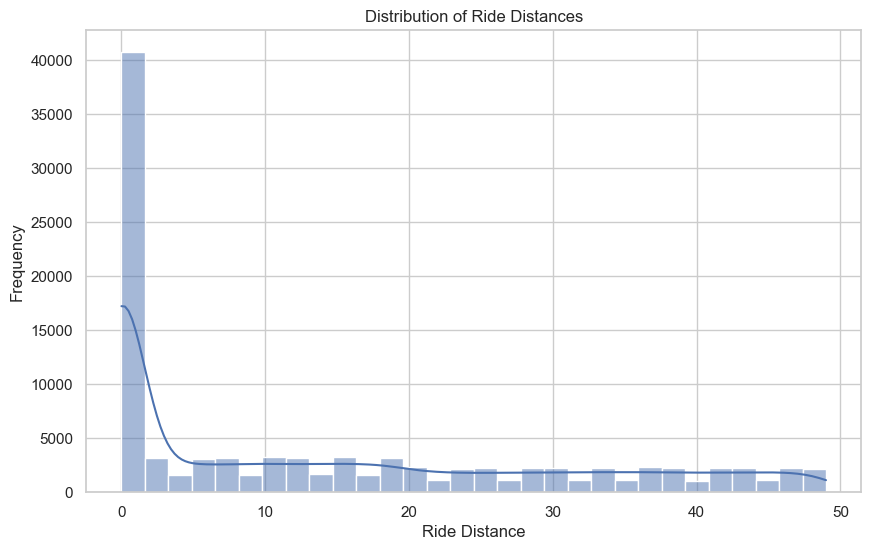

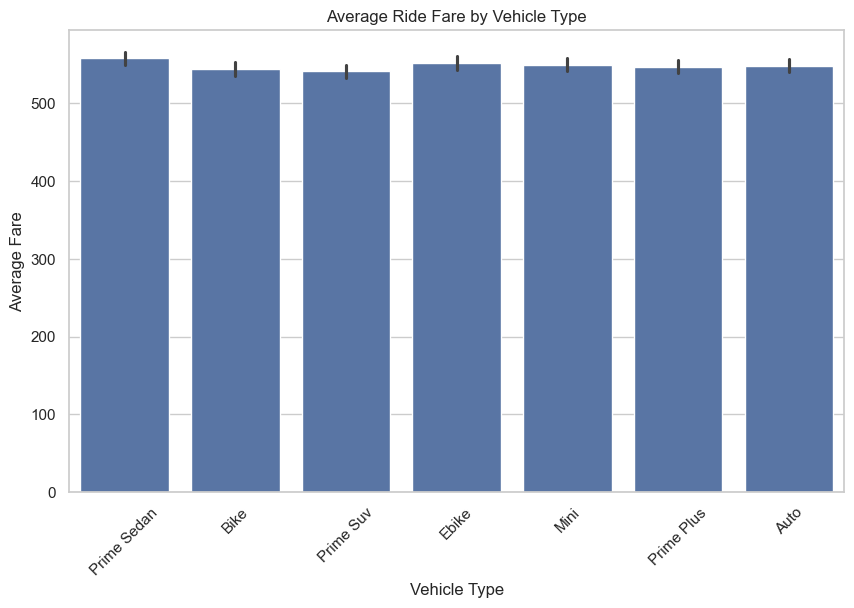

In [9]:
# Visualizations

# Distribution of ride distances
plt.figure(figsize=(10, 6))
sns.histplot(df['Ride_Distance'], bins=30, kde=True)
plt.title('Distribution of Ride Distances')
plt.xlabel('Ride Distance')
plt.ylabel('Frequency')
plt.show()

# Average ride fare by vehicle type
plt.figure(figsize=(10, 6))
sns.barplot(x='Vehicle_Type', y='Booking_Value', data=df, estimator=np.mean)
plt.title('Average Ride Fare by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Average Fare')
plt.xticks(rotation=45)
plt.show()

In [8]:
# Conclusions
print("This section will summarize the key findings from the EDA.")

This section will summarize the key findings from the EDA.
